In [1]:
# ============================================
# Libraries
# ============================================

library(tidyverse)
library(ComplexUpset)
library(ComplexHeatmap)
library(patchwork)
library(scales)

sessionInfo()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformati

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 26.04 LTS

Matrix products: default
BLAS/LAPACK: /home/ha-ibnu/miniconda3/envs/r-viz/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Asia/Tokyo
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] scales_1.4.0          patchwork_1.3.2       ComplexHeatmap_2.18.0
 [4] ComplexUpset_1.3.3    lubridate_1.9.4       forcats_1.0.0        
 [7] stringr_1.5.2         dplyr_1.1.4           purrr_1.1.0          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.3.

In [2]:
# ============================================
# Paths
# ============================================

RESULT_DIR <- "../results"

LGBM_DIR <- file.path(RESULT_DIR, "lgbm")
RF_DIR   <- file.path(RESULT_DIR, "rf")

FIGURE_DIR <- file.path(RESULT_DIR, "figures")
dir.create(FIGURE_DIR, recursive = TRUE, showWarnings = FALSE)

print(normalizePath(RESULT_DIR))
print(normalizePath(LGBM_DIR))
print(normalizePath(FIGURE_DIR))

[1] "/home/ha-ibnu/Code/regression/results"
[1] "/home/ha-ibnu/Code/regression/results/lgbm"
[1] "/home/ha-ibnu/Code/regression/results/figures"


In [3]:
# ============================================
# Load OS21 LGBM region fold data
# ============================================

region_fold <- read_tsv(
  file.path(LGBM_DIR, "OS21.lgbm.cv_by_region_folds.tsv"),
  show_col_types = FALSE
)

glimpse(region_fold)
head(region_fold)

Rows: 150
Columns: 8
$ species    <chr> "OS21", "OS21", "OS21", "OS21", "OS21", "OS21", "OS21", "OS…
$ model      <chr> "LightGBM", "LightGBM", "LightGBM", "LightGBM", "LightGBM",…
$ combo      <chr> "3'UTR", "3'UTR", "3'UTR", "3'UTR", "3'UTR", "3'UTR", "3'UT…
$ sets       <chr> "[\"3'UTR\"]", "[\"3'UTR\"]", "[\"3'UTR\"]", "[\"3'UTR\"]",…
$ fold       <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9,…
$ R2_CV      <dbl> 0.3103672, 0.1917029, 0.2302344, 0.3032009, 0.2571327, 0.29…
$ n_sets     <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ n_features <dbl> 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 93, 93, 93, 93, 93,…


species,model,combo,sets,fold,R2_CV,n_sets,n_features
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
OS21,LightGBM,3'UTR,"[""3'UTR""]",0,0.3103672,1,92
OS21,LightGBM,3'UTR,"[""3'UTR""]",1,0.1917029,1,92
OS21,LightGBM,3'UTR,"[""3'UTR""]",2,0.2302344,1,92
OS21,LightGBM,3'UTR,"[""3'UTR""]",3,0.3032009,1,92
OS21,LightGBM,3'UTR,"[""3'UTR""]",4,0.2571327,1,92
OS21,LightGBM,3'UTR,"[""3'UTR""]",5,0.2947699,1,92


In [8]:
# ============================================
# Clean region membership data
# ============================================

REGION_SETS <- c("mRNA", "CDS", "5'UTR", "3'UTR")

parse_region_sets <- function(x) {
  str_extract_all(
    x,
    "mRNA|CDS|5'UTR|3'UTR"
  )[[1]]
}

region_df <- region_fold |>
  mutate(
    sets_clean = map(sets, parse_region_sets),
    combo_label = str_replace_all(combo, "\\+", " + ")
  )

for (set_name in REGION_SETS) {
  region_df[[set_name]] <- map_lgl(
    region_df$sets_clean,
    ~ set_name %in% .x
  )
}

combo_df <- region_df |>
  distinct(
    combo_label,
    across(all_of(REGION_SETS)),
    n_features
  ) |>
  mutate(
    n_sets = rowSums(across(all_of(REGION_SETS))),
    comb_code = paste0(
      as.integer(mRNA),
      as.integer(CDS),
      as.integer(`5'UTR`),
      as.integer(`3'UTR`)
    )
  ) |>
  arrange(n_sets, combo_label)

combo_df

combo_label,mRNA,CDS,5'UTR,3'UTR,n_features,n_sets,comb_code
<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<chr>
3'UTR,FALSE,FALSE,FALSE,TRUE,92,1,0001
5'UTR,FALSE,FALSE,TRUE,FALSE,93,1,0010
CDS,FALSE,TRUE,FALSE,FALSE,189,1,0100
mRNA,TRUE,FALSE,FALSE,FALSE,1,1,1000
3'UTR + mRNA,TRUE,FALSE,FALSE,TRUE,93,2,1001
5'UTR + 3'UTR,FALSE,FALSE,TRUE,TRUE,185,2,0011
5'UTR + CDS,FALSE,TRUE,TRUE,FALSE,282,2,0110
5'UTR + mRNA,TRUE,FALSE,TRUE,FALSE,94,2,1010
CDS + 3'UTR,FALSE,TRUE,FALSE,TRUE,281,2,0101


In [9]:
# ============================================
# Prepare R2 values per combination
# ============================================

region_df <- region_df |>
  mutate(
    comb_code = paste0(
      as.integer(mRNA),
      as.integer(CDS),
      as.integer(`5'UTR`),
      as.integer(`3'UTR`)
    )
  )

comb_order <- combo_df$comb_code

r2_list <- lapply(comb_order, function(code) {
  region_df |>
    filter(comb_code == code) |>
    pull(R2_CV)
})

names(r2_list) <- comb_order

str(r2_list)

List of 15
 $ 0001: num [1:10] 0.31 0.192 0.23 0.303 0.257 ...
 $ 0010: num [1:10] 0.457 0.281 0.341 0.413 0.352 ...
 $ 0100: num [1:10] 0.386 0.261 0.311 0.398 0.328 ...
 $ 1000: num [1:10] 0.08222 -0.00915 0.01725 0.07333 0.04037 ...
 $ 1001: num [1:10] 0.33 0.202 0.241 0.326 0.262 ...
 $ 0011: num [1:10] 0.404 0.253 0.313 0.424 0.338 ...
 $ 0110: num [1:10] 0.465 0.263 0.389 0.45 0.366 ...
 $ 1010: num [1:10] 0.455 0.273 0.353 0.441 0.373 ...
 $ 0101: num [1:10] 0.353 0.232 0.314 0.381 0.293 ...
 $ 1100: num [1:10] 0.402 0.26 0.334 0.416 0.328 ...
 $ 1011: num [1:10] 0.422 0.264 0.331 0.426 0.354 ...
 $ 0111: num [1:10] 0.413 0.274 0.354 0.44 0.343 ...
 $ 1110: num [1:10] 0.455 0.295 0.391 0.454 0.369 ...
 $ 1101: num [1:10] 0.37 0.226 0.298 0.376 0.298 ...
 $ 1111: num [1:10] 0.427 0.263 0.365 0.442 0.341 ...


In [12]:
# ============================================
# Build ComplexHeatmap UpSet object
# ============================================

# True feature set sizes
region_set_size <- c(
  "mRNA"  = 1,
  "CDS"   = 189,
  "5'UTR" = 93,
  "3'UTR" = 92
)

# Matrix used only to define the UpSet combination layout
upset_input_mat <- combo_df |>
  select(all_of(REGION_SETS)) |>
  as.matrix()

rownames(upset_input_mat) <- combo_df$combo_label
upset_input_mat <- upset_input_mat * 1

# Make ComplexHeatmap combination matrix
m <- make_comb_mat(
  upset_input_mat,
  mode = "distinct"
)

# Force combination order to match combo_df
m <- m[, combo_df$comb_code]

# Reorder R2 list to match combination matrix
r2_list_ordered <- r2_list[comb_name(m)]

# Check
comb_name(m)
set_name(m)

[1] "0001" "0010" "0100" "1000" "1001" "0011" "0110" "1010" "0101" "1100"
[11] "1011" "0111" "1110" "1101" "1111"

[1] "mRNA"  "CDS"   "5'UTR" "3'UTR"

'heatmap_width' should not be set in draw() for horizontal heatmap list
(Note a single heatmap is a horizontal heatmap list). Please directly
set it in `Heatmap()`.



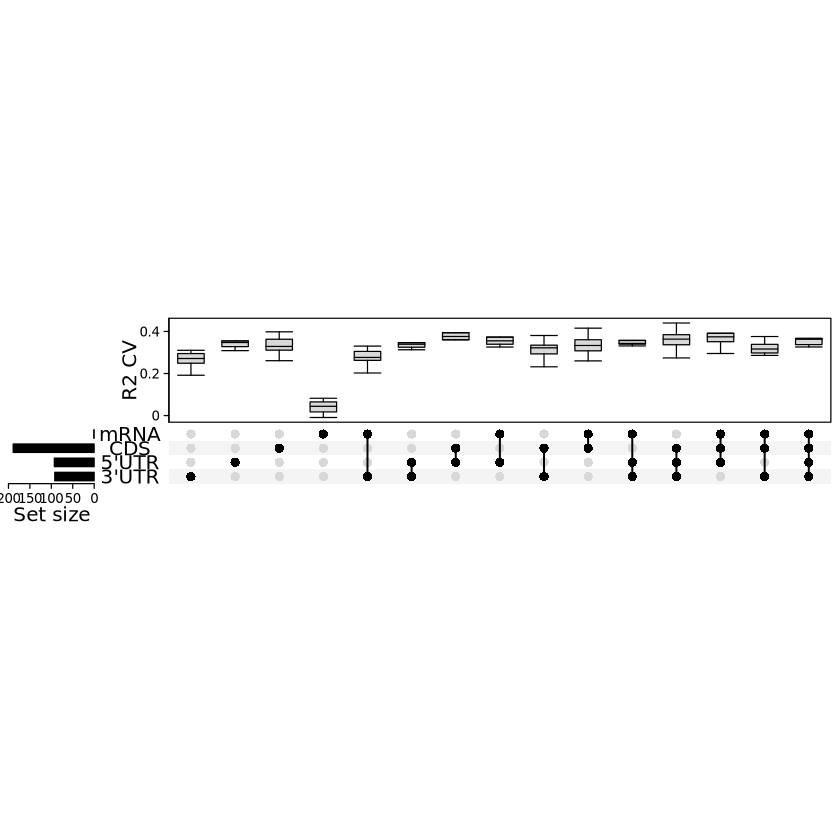

In [24]:
# ============================================
# Better proportion version
# ============================================

top_ha <- HeatmapAnnotation(
  "R2 CV" = anno_boxplot(
    r2_list_ordered,
    outline = FALSE,
    gp = gpar(fill = "grey85", col = "black"),
    height = unit(2.2, "cm")
  ),
  annotation_name_side = "left",
  annotation_name_rot = 90
)

left_ha <- rowAnnotation(
  "Set size" = anno_barplot(
    -region_set_size[set_name(m)],
    baseline = 0,
    border = FALSE,
    gp = gpar(fill = "black"),
    axis_param = list(
      at = -c(0, 50, 100, 150, 200),
      labels = c(0, 50, 100, 150, 200),
      labels_rot = 0
    ),
    width = unit(1.8, "cm")
  ),
  set_name = anno_text(
    set_name(m),
    location = 0.5,
    just = "center",
    width = max_text_width(set_name(m)) + unit(2, "mm")
  ),
  annotation_name_side = "bottom"
)

ht <- UpSet(
  m,
  set_order = set_name(m),
  comb_order = seq_along(comb_name(m)),
  top_annotation = top_ha,
  left_annotation = left_ha,
  right_annotation = NULL,
  show_row_names = FALSE,
  pt_size = unit(2.6, "mm"),
  lwd = 1.6,
  bg_col = c("#F4F4F4", "#FFFFFF"),
  bg_pt_col = "#D8D8D8",
  comb_col = "black"
)

draw(
  ht,
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(3.5, "cm")
)